# **6.9 Finance Time Series 데이터 활용하기 (2)**

<br>

## **9-6. 프로젝트: Finance Time Series 데이터 활용하기**

---

### **프로젝트 요약**

이번 노드에서 프로젝트는 총 3가지로 구성되어있습니다.

- 프로젝트 1: Data Labeling
- 프로젝트 2: Feature Engineering
- 프로젝트 3: Model Training

Data Labeling 방법과 Feature Engineering 방법에 대해 생각해보며 model training을 통해 성능을 개선시켜봅시다.

- 프로젝트 1, 2를 정상적인 흐름대로 진행하기
- 프로젝트 3에서 다양한 방법을 사용하여 기존의 결과와 비교 분석 시도하기
- 다양한 방법을 사용하여 성능향상을 시도하기

<br>

## **프로젝트 1: Data Labeling**

---

위에서 배운 Data Labeling 4가지를 직접 적용해봅시다.

① Price Change Direction 적용하기

② Using Moving Average 적용하기

③ Local Min-Max 적용하기

④ Trend Scanning 적용하기

<br>

**필요한 라이브러리 및 패키지 확인 후 실행**

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

**데이터 로드 및 시각화**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<Axes: xlabel='time'>

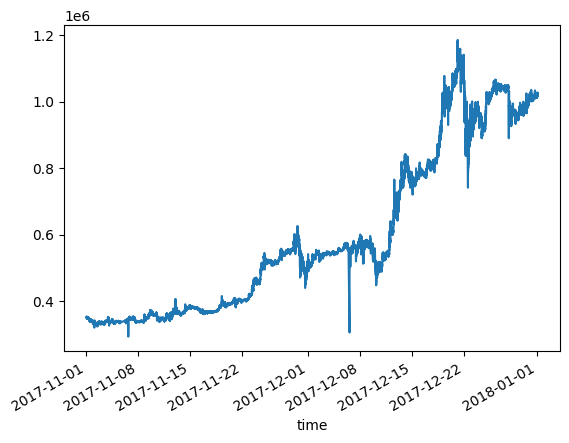

In [4]:
# 데이터 경로
DATA_PATH = '/content/drive/MyDrive/DS_8th/06_금융 시계열 분석하기/45일차_2 24(화)_시계열분석 기초_09(프로젝트)/data'

# 데이터 불러오기
modify_data = pd.read_csv(os.path.join(DATA_PATH, 'sub_upbit_eth_min_tick.csv'), index_col=0, parse_dates=True)

# 불러온 데이터 시각화하기
modify_data.loc['2017-11-01':'2017-12-31','close'].plot()

<br>

### **① Price Change Direction 적용하기**

(중략)

먼저 window를 설정합니다...

In [5]:
# Q. 코드를 작성해주세요

In [6]:
# window 지정
window = 10 # 앞서 사용한 window의 값은 10입니다.

# momentum_signal 만들기
momentum_signal = np.sign(np.sign(modify_data['close'] - modify_data['close'].shift(window)) + 1) # modify_data['close'].shift(window)활용

# s_momentum_signal 만들기
s_momentum_signal = pd.Series(momentum_signal, index=modify_data.index) # 데이터 활용을 위해 pd.Series를 사용합니다.

기존의 데이터(modify_data)에서 필요한 close(종가)를 가져오고

수식이 적용된 데이터(s_momentum_signal)의 종가와 얼마나 차이가 있는지 확인하기 위해

데이터를 변환하고 시각화합니다.

In [7]:
# Q. 코드를 작성해주세요

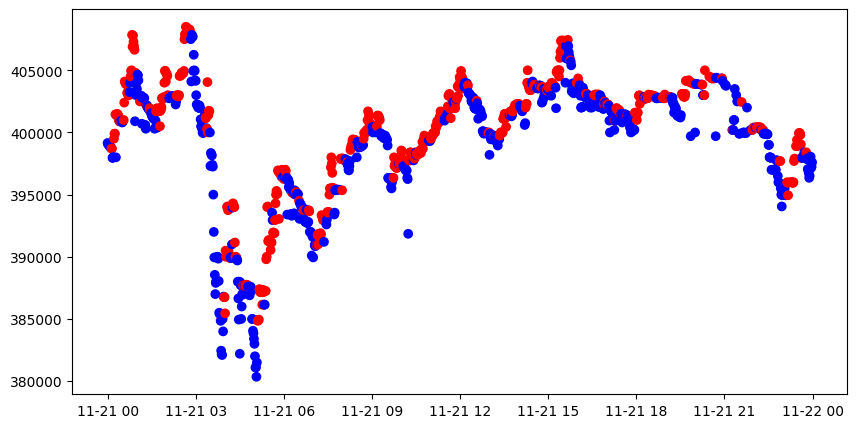

In [8]:
# 기존 데이터 만들기
sub_data = modify_data.loc['2017-11-21', 'close'] # loc를 활용하여 2017-11-21부터 close(종가)까지 가져오기

# 수식 적용된 데이터 만들기
c_sig = s_momentum_signal.loc['2017-11-21'] # loc를 활용하여 2017-11-21의 시간대별 값을 가져오기

# 두 데이터의 비교를 위한 색상 바꾸기
c_sig['color'] = np.where(c_sig == 1, 'red', 'blue') # np.where 사용

# 시각화하기
plt.figure(figsize=(10,5))
plt.scatter(sub_data.index, sub_data, c=c_sig['color'])

<br>

### **② Using Moving Average 적용하기**

(중략)

In [9]:
# Q. 코드를 작성해주세요

In [10]:
# momentum_signal
momentum_signal = np.sign(np.sign(modify_data['close'] - modify_data['close'].rolling(window).mean()) + 1) # modify_data['close'].rolling(window).mean() 활용

# s_momentum_signal
s_momentum_signal = pd.Series(momentum_signal, index=modify_data.index) # pd.Series로 변환

앞서 "① Price Change Direction 적용하기"에서 진행했던 것처럼

시각화를 위해 Using Moving Average 수식을 적용한 것과 비교하기 위해

데이터를 변환하여 시각화를 통해 확인합니다.

In [11]:
# Q. 코드를 작성해주세요

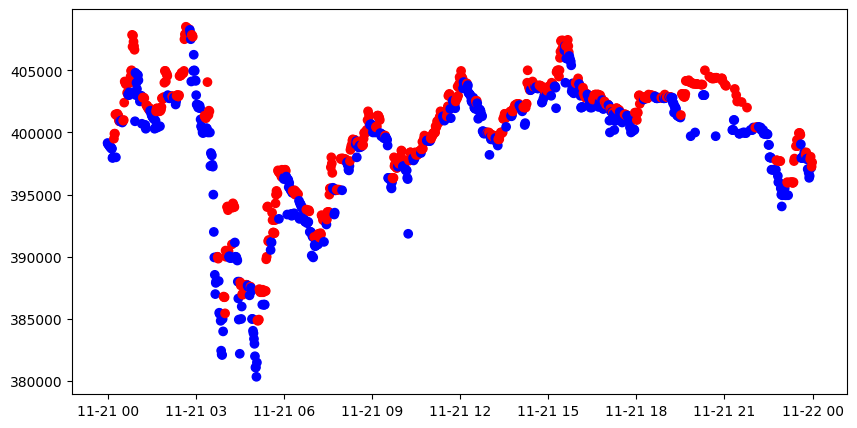

In [12]:
# 기존 데이터 만들기
sub_data = modify_data.loc['2017-11-21', 'close']

# 수식 적용된 데이터 만들기
c_sig = s_momentum_signal.loc['2017-11-21']

# 두 데이터의 비교를 위한 색상 바꾸기
c_sig['color'] = np.where(c_sig == 1, 'red', 'blue')

# 시각화하기
plt.figure(figsize=(10,5))
plt.scatter(sub_data.index, sub_data, c=c_sig['color'])

<br>

### **③ Local Min-Max 적용하기**

(중략)

①~⑦까지 코드를 자세히 들여다보고 어떠한 방식으로 코드가 동작되는지 뜯어봅시다.

⑧ return 값은 dictionary 형태로 2개의 DataFrame이 반환되어야합니다.

In [13]:
# Q. 코드를 작성해주세요

In [14]:
# Local min / max 를 추출하기 위한 함수
def get_local_min_max(close, wait=3):
    min_value = close.iloc[0]
    max_value = close.iloc[0] # ①
    n_cnt_min, n_cnt_max = 0, 0

    mins, maxes = [], []
    min_idxes, max_idxes = [], []
    b_min_update, b_max_update = False, False

    for idx, val in zip(close.index[1:], close.values[1:]):
        if val < min_value:
            min_value = val
            mins.append(min_value)
            min_idxes.append(idx)
            n_cnt_min = 0
            b_min_update = True
        if val > max_value:
            max_value = val # ②
            maxes.append(max_value) # ③
            max_idxes.append(idx)
            n_cnt_max = 0
            b_max_update = True # ④

        if not b_max_update:
            b_min_update = False
            n_cnt_min += 1
            if n_cnt_min >= wait:
                max_value = min_value
                n_cnt_min = 0

        if not b_min_update:
            b_max_update = False # ⑤
            n_cnt_max += 1 # ⑥
            if n_cnt_max >= wait:
                min_value = max_value # ⑦
                n_cnt_max = 0

    return pd.DataFrame.from_dict({'min_time': min_idxes, 'local_min': mins}), pd.DataFrame.from_dict({'max_time': max_idxes, 'local_max': maxes}) # ⑧

get_local_min_max 함수를 사용하면 return 값이 2개가 나오게 됩니다.

아래 주석을 제거하여 min과 maxes의 값이 어떻게 나오는지 확인해봅시다.

In [15]:
# Local mins, maxes를 확인
mins, maxes = get_local_min_max(sub_data, wait=3)

# mins, maxes 확인
print(mins)
print('--'*20)
print(maxes)

               min_time  local_min
0   2017-11-21 00:01:00     399050
1   2017-11-21 00:03:00     399000
2   2017-11-21 00:04:00     398900
3   2017-11-21 00:05:00     398850
4   2017-11-21 00:06:00     398800
..                  ...        ...
472 2017-11-21 23:48:00     397850
473 2017-11-21 23:50:00     397050
474 2017-11-21 23:52:00     396750
475 2017-11-21 23:53:00     396350
476 2017-11-21 23:59:00     397600

[477 rows x 2 columns]
----------------------------------------
               max_time  local_max
0   2017-11-21 00:13:00     399500
1   2017-11-21 00:14:00     399900
2   2017-11-21 00:16:00     401450
3   2017-11-21 00:19:00     401350
4   2017-11-21 00:20:00     401500
..                  ...        ...
268 2017-11-21 23:41:00     398050
269 2017-11-21 23:43:00     398400
270 2017-11-21 23:46:00     398200
271 2017-11-21 23:47:00     398400
272 2017-11-21 23:56:00     398050

[273 rows x 2 columns]


In [16]:
# Q. 코드를 작성해주세요

(376546.5, 412585.0)

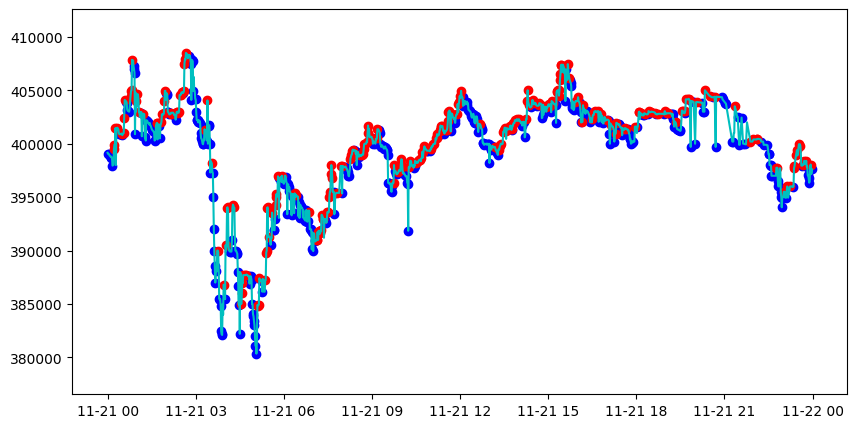

In [17]:
# subplots 및 plot 생성
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(sub_data, 'c')

# min_time, local_min을 활용한 scatter plot 생성
ax.scatter(mins.min_time, mins.local_min, c='blue')

# maxes_time, local_max를 활용한 scatter plot 생성
ax.scatter(maxes.max_time, maxes.local_max, c='red')

# y축 설정
ax.set_ylim([sub_data.min() * 0.99, sub_data.max()  * 1.01])

<br>

### **④ Trend Scanning 적용하기**

(중략)

OLS는 회귀분석을 하는 경우 유용하게 사용할 수 있으며

아래 함수에서 ols.tvalue를 통해 t-value값을 사용할 수 있는 함수를 활용하여

추세(trend)를 추정합니다.

In [18]:
def t_val_lin_r(close):
    import statsmodels.api as sml

    # t-value from a linear trend
    x = np.ones((close.shape[0], 2))
    x[:, 1] = np.arange(close.shape[0])
    ols = sml.OLS(close, x).fit()
    return ols.tvalues[1]

In [19]:
look_forward_window = 60
min_sample_length = 5
step = 1
t1_array = []
t_values_array = []

In [20]:
# Q. 코드를 작성해주세요.
# 이 코드 블럭은 실행에 20-30분정도가 소요될 수 있습니다.

In [21]:
molecule = modify_data['2017-11-01':'2017-11-30'].index
label = pd.DataFrame(index=molecule, columns=['t1', 't_val', 'bin'])
tmp_out = []

for ind in tqdm(molecule):
    subset = modify_data.loc[ind:, 'close'].iloc[:look_forward_window]  # 전방 탐색을 위한 샘플 추출
    if look_forward_window > subset.shape[0]:
        continue

    tmp_subset = pd.Series(index=subset.index[min_sample_length-1:subset.shape[0]-1])
    tval = []

    # 회귀분석을 통해 t 통계량값을 이용하여 추세 추정
    for forward_window in np.arange(min_sample_length, subset.shape[0]):
        df = subset.iloc[:forward_window]
        tval.append(t_val_lin_r(df.values))  # t-value 사용

    tmp_subset.loc[tmp_subset.index] = np.array(tval)
    idx_max = tmp_subset.replace([-np.inf, np.inf, np.nan], 0).abs().idxmax()
    tmp_t_val = tmp_subset[idx_max]
    tmp_out.append([tmp_subset.index[-1], tmp_t_val, np.sign(tmp_t_val)])

label.loc[molecule] = np.array(tmp_out)  # prevent leakage

label['t1'] = pd.to_datetime(label['t1'])
label['bin'] = pd.to_numeric(label['bin'], downcast='signed')

100%|██████████| 33384/33384 [15:02<00:00, 36.97it/s]


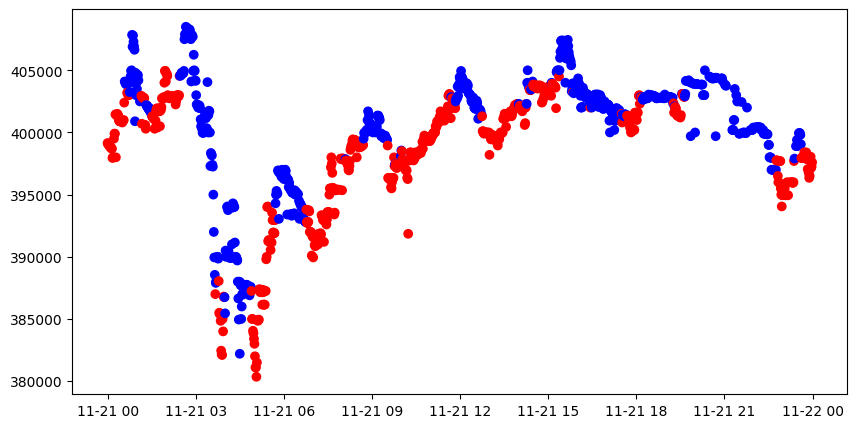

In [22]:
# 시각화
sub_data = modify_data.loc['2017-11-21', 'close']
c_sig = label['bin'].loc['2017-11-21']
c_sig['color'] = np.where(c_sig == 1, 'red', 'blue')

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(sub_data.index, sub_data.values, c=c_sig['color'])

<br><br>

## **프로젝트 2: Feature Engineering**

---

① 환경구성 및 데이터 불러오기

② Technical Index 적용하기

③ Feature Selection methods 적용하기

<br>

#### **환경구성 및 데이터 불러오기**

In [23]:
!pip install ta==0.9.0
!pip install shap

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.9.0-py3-none-any.whl size=28893 sha256=6154c016370a4414068f7164598af0bd54a78f26d9fa8c1a08cc137657ec8a4f
  Stored in directory: /root/.cache/pip/wheels/41/9d/74/9461cc3506f46d0ab93664f8168d974d944b57bb15f24d9e55
Successfully built ta


In [24]:
import datetime
import sys
import os
import re
import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ta

import sys
sys.path.append('/content/drive/MyDrive/DS_8th/06_금융 시계열 분석하기/45일차_2 24(화)_시계열분석 기초_09(프로젝트)/fnguide/data/')
from libs.feature_importance import importance as imp
from sklearn.feature_selection import SequentialFeatureSelector, RFECV

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [25]:
# 데이터 경로 설정
DATA_PATH = '/content/drive/MyDrive/DS_8th/06_금융 시계열 분석하기/45일차_2 24(화)_시계열분석 기초_09(프로젝트)/data'
anno_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_tick_label.pkl')
target_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_tick.csv')

# 데이터 불러오기
df_modify_data = pd.read_csv(target_file_name, index_col=0, parse_dates=True)
df_label_data = pd.read_pickle(anno_file_name)
df_sub_modify_data = df_modify_data.loc[df_label_data.index]

# 학습 시간 단축을 위해 여기선 편의상 1000개의 데이터만 가져옵니다.
df_sub_modify_data = df_sub_modify_data.iloc[:1000]

In [26]:
df_sub_modify_data.head()

,open,high,low,close,volume
time,,,,,
2018-01-01 00:00:00,1028000,1028000,1026500,1028000,41.835689
2018-01-01 00:01:00,1028000,1029000,1026000,1028500,22.307810
2018-01-01 00:02:00,1028000,1029000,1028000,1028000,59.276102
2018-01-01 00:03:00,1028000,1028000,1014000,1014000,114.203740
2018-01-01 00:04:00,1020000,1027000,1014500,1025000,62.695404


In [27]:
df_label_data.head(), df_label_data.tail()

(time
 2018-01-01 00:00:00   -0.0
 2018-01-01 00:01:00   -0.0
 2018-01-01 00:02:00   -0.0
 2018-01-01 00:03:00   -1.0
 2018-01-01 00:04:00   -1.0
 Name: t_value, dtype: float64,
 time
 2019-11-03 10:29:00   NaN
 2019-11-03 10:30:00   NaN
 2019-11-03 10:31:00   NaN
 2019-11-03 10:32:00   NaN
 2019-11-03 10:33:00   NaN
 Name: t_value, dtype: float64)

In [28]:
df_label_data.value_counts()

,count
t_value,
-1.0,306636
-0.0,302963
1.0,299289


<br>

### **① Technical Index 적용하기**

앞서 배운 기술적 지표와 수익률/변동성 지표를 참고하여 코드를 뜯어봅시다.

In [29]:
# 기술적 지표를 적용합니다.

In [30]:
mt = 1
fillna = False
df_ = df_sub_modify_data.copy()
open, high, low, close, volume = 'open', 'high', 'low', 'close', 'volume'
cols = [open, high, low, close, volume]

## Volume Index
# Chaikin Money Flow
df_["volume_cmf"] = ta.volume.ChaikinMoneyFlowIndicator(
                        high=df_[high], low=df_[low], close=df_[close], volume=df_[volume], window=20*mt, fillna=fillna
                    ).chaikin_money_flow()
# Force Index
df_["volume_fi"] = ta.volume.ForceIndexIndicator(
                        close=df_[close], volume=df_[volume], window=15*mt, fillna=fillna
                    ).force_index()
# Money Flow Indicator
df_["volume_mfi"] = ta.volume.MFIIndicator(
                        high=df_[high],
                        low=df_[low],
                        close=df_[close],
                        volume=df_[volume],
                        window=15*mt,
                        fillna=fillna,
                    ).money_flow_index()
# Ease of Movement
df_["volume_sma_em"] = ta.volume.EaseOfMovementIndicator(
                            high=df_[high], low=df_[low], volume=df_[volume], window=15*mt, fillna=fillna
                        ).sma_ease_of_movement()

# Volume Price Trend
df_["volume_vpt"] = ta.volume.VolumePriceTrendIndicator(
                        close=df_[close], volume=df_[volume], fillna=fillna
                    ).volume_price_trend()

## volatility index
# Average True Range
df_["volatility_atr"] = ta.volatility.AverageTrueRange(
                            close=df_[close], high=df_[high], low=df_[low], window=10*mt, fillna=fillna
                        ).average_true_range()

# Ulcer Index
df_["volatility_ui"] = ta.volatility.UlcerIndex(
                            close=df_[close], window=15*mt, fillna=fillna
                        ).ulcer_index()

## trend index
# MACD
df_["trend_macd_diff"] = ta.trend.MACD(
                            close=df_[close], window_slow=25*mt, window_fast=10*mt, window_sign=9, fillna=fillna
                        ).macd_diff()

# Average Directional Movement Index (ADX)
df_["trend_adx"] = ta.trend.ADXIndicator(
                        high=df_[high], low=df_[low], close=df_[close], window=15*mt, fillna=fillna
                    ).adx()

# TRIX Indicator
df_["trend_trix"] = ta.trend.TRIXIndicator(
                        close=df_[close], window=15*mt, fillna=fillna
                    ).trix()

# Mass Index
df_["trend_mass_index"] = ta.trend.MassIndex(
                            high=df_[high], low=df_[low], window_fast=10*mt, window_slow=25*mt, fillna=fillna
                        ).mass_index()

# DPO Indicator
df_["trend_dpo"] = ta.trend.DPOIndicator(
                        close=df_[close], window=20*mt, fillna=fillna
                    ).dpo()

# Aroon Indicator
df_["trend_aroon_ind"] = ta.trend.AroonIndicator(close=df_[close], window=20, fillna=fillna).aroon_indicator()

## momentum index
# Relative Strength Index (RSI)
df_["momentum_rsi"] = ta.momentum.RSIIndicator(close=df_[close], window=15*mt, fillna=fillna).rsi()

# Williams R Indicator
df_["momentum_wr"] = ta.momentum.WilliamsRIndicator(
                        high=df_[high], low=df_[low], close=df_[close], lbp=15*mt, fillna=fillna
                    ).williams_r()

In [31]:
df_

,open,high,low,close,volume,volume_cmf,volume_fi,volume_mfi,volume_sma_em,volume_vpt,volatility_atr,volatility_ui,trend_macd_diff,trend_adx,trend_trix,trend_mass_index,trend_dpo,trend_aroon_ind,momentum_rsi,momentum_wr
time,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,1028000,1028000,1026500,1028000,41.835689,NaN,NaN,NaN,NaN,-0.796083,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:01:00,1028000,1029000,1026000,1028500,22.307810,NaN,NaN,NaN,NaN,-0.788285,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:02:00,1028000,1029000,1028000,1028000,59.276102,NaN,NaN,NaN,NaN,-0.017967,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:03:00,1028000,1028000,1014000,1014000,114.203740,NaN,NaN,NaN,NaN,-1.584121,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01 00:04:00,1020000,1027000,1014500,1025000,62.695404,NaN,NaN,NaN,NaN,-0.875176,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 16:35:00,1052500,1052500,1052500,1052500,6.084122,-0.232633,-2275.848327,71.279251,-3.186964e+12,0.007381,1416.425464,0.361107,652.357742,20.661135,-0.018034,23.066052,-225.0,-35.0,52.934202,-0.0
2018-01-01 16:36:00,1052500,1052500,1049500,1050000,9.205537,-0.165805,-4868.097577,67.762226,-3.097651e+12,-0.021866,1574.782918,0.349329,482.768654,21.007559,-0.016660,23.029259,-2100.0,-35.0,44.041843,-62.5
2018-01-01 16:37:00,1050000,1050000,1049000,1049000,3.472849,-0.161093,-4693.691500,74.267351,-5.977131e+12,-0.025173,1517.304626,0.342452,280.010175,21.537826,-0.015683,22.971985,-1925.0,-35.0,41.083991,-87.5


In [32]:
# 수익률 / 변동성 지표를 적용합니다.

In [33]:
windows_mom = [5, 10, 20]
windows_std = [30]

for i in windows_mom:
    df_[f'vol_change_{i}'] = df_.volume.pct_change(i).round(6)
    df_[f'ret_{i}'] = df_.close.pct_change(i).round(6)

for i in windows_std:
    df_[f'std_{i}'] = df_.close.rolling(i).std()
    df_[f'vol_std_{i}'] = df_.volume.rolling(i).std()

In [34]:
# Q. 코드를 작성해주세요

In [35]:
df_tmp_data = df_.join(df_label_data).dropna()

# X, y 데이터셋 만들기
X = df_tmp_data.iloc[:, 5:-1]
y = df_tmp_data.iloc[:, -1] # iloc[:, -1] 사용

# StandardScaler 적용
sc = StandardScaler()

# fit_transform 사용
X_sc = sc.fit_transform(X)

# DataFrame 변환
X_sc = pd.DataFrame(X_sc, index=X.index, columns=X.columns)

In [36]:
X_sc.head()

,volume_cmf,volume_fi,volume_mfi,volume_sma_em,volume_vpt,volatility_atr,volatility_ui,trend_macd_diff,trend_adx,trend_trix,...,momentum_rsi,momentum_wr,vol_change_5,ret_5,vol_change_10,ret_10,vol_change_20,ret_20,std_30,vol_std_30
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:43:00,1.035464,-0.186753,0.065427,0.391695,0.143181,1.474065,0.054076,0.103695,0.930692,-0.078062,...,-0.141586,0.073599,-0.268825,-0.053926,-0.273922,-0.077989,-0.359687,0.617241,-0.335632,0.273404
2018-01-01 00:44:00,1.054026,0.125880,-0.011156,0.814123,0.544363,1.478520,0.017250,0.639945,0.771813,-0.051294,...,0.344922,1.111779,-0.209690,2.237163,-0.263511,0.036043,-0.266915,0.940844,-0.262646,0.291664
2018-01-01 00:45:00,1.042978,-0.023653,0.063195,1.052689,0.218332,1.290057,-0.020738,0.714133,0.598850,-0.015958,...,0.067032,0.544625,-0.124252,0.554780,-0.278339,0.150308,-0.252720,0.942325,-0.237456,0.301886
2018-01-01 00:46:00,1.016133,0.880060,-0.281931,0.928143,1.068429,1.633699,-0.020738,1.434675,0.454452,0.071047,...,0.783648,1.457839,0.168697,2.536405,-0.228841,0.833801,-0.227291,1.672326,-0.022928,0.256716
2018-01-01 00:47:00,0.893440,0.486864,-0.562722,-0.026395,0.862103,1.942977,0.088583,0.921217,0.319680,0.131133,...,-0.191611,-0.257415,-0.080204,0.402681,-0.380178,0.036276,-0.340320,0.454122,-0.018291,0.317671


In [37]:
# Q. 코드를 작성해주세요

In [38]:
# RandomForest 모델 적용
rfc = RandomForestClassifier(class_weight='balanced')

# RandomForest fit 하기
rfc.fit(X_sc, y)

RandomForestClassifier(class_weight='balanced')

<br>

### **③ Feature Selection methods 적용하기**

#### **MDI, Mean Decrease Impurity**

In [39]:
# MDI, Mean Decrease Impurity
feat_imp = imp.mean_decrease_impurity(rfc, X.columns)
feat_imp

,mean,std
volume_cmf,0.049611,0.002180
volume_fi,0.043486,0.002509
volume_mfi,0.041874,0.002556
volume_sma_em,0.036472,0.001851
volume_vpt,0.025535,0.001361
volatility_atr,0.079491,0.003427
volatility_ui,0.045934,0.002242
trend_macd_diff,0.078209,0.004204
trend_adx,0.052120,0.002353
trend_trix,0.071863,0.003092


<br>

#### **MDA, Mean Decrease Accuracy**

In [40]:
# MDA, Mean Decrease Accuracy
svc_rbf = SVC(kernel='rbf', probability=True) # Tree 및 Support Vector Machine 외에 다른 분류기(classifier)를 사용해봅시다.
cv = KFold(n_splits=5) # n_splits을 변경해봅시다.
feat_imp_mda = imp.mean_decrease_accuracy(svc_rbf, X_sc, y, cv_gen=cv)

In [41]:
# plot_feature_importance 함수 만들기
def plot_feature_importance(importance_df, save_fig=False, output_path=None):
    # Plot mean imp bars with std
    plt.figure(figsize=(10, importance_df.shape[0] / 5))
    importance_df.sort_values('mean', ascending=True, inplace=True)
    importance_df['mean'].plot(kind='barh', color='b', alpha=0.25, xerr=importance_df['std'], error_kw={'ecolor': 'r'})
    if save_fig:
        plt.savefig(output_path)
    else:
        plt.show()

In [42]:
# Q. 코드를 작성해주세요

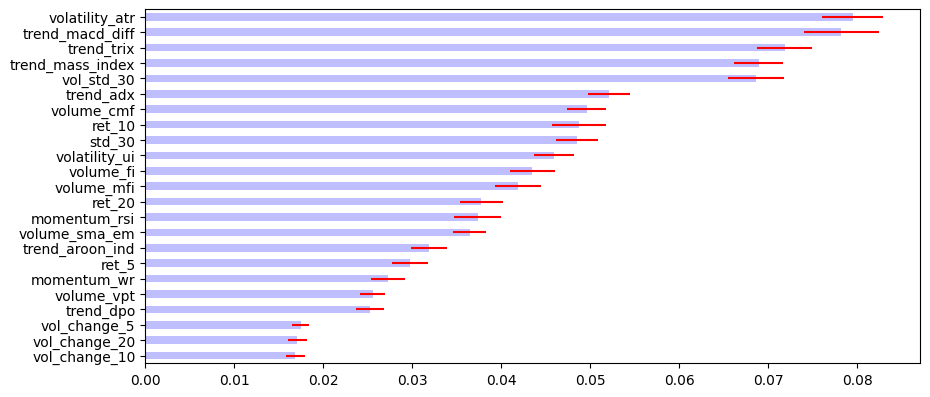

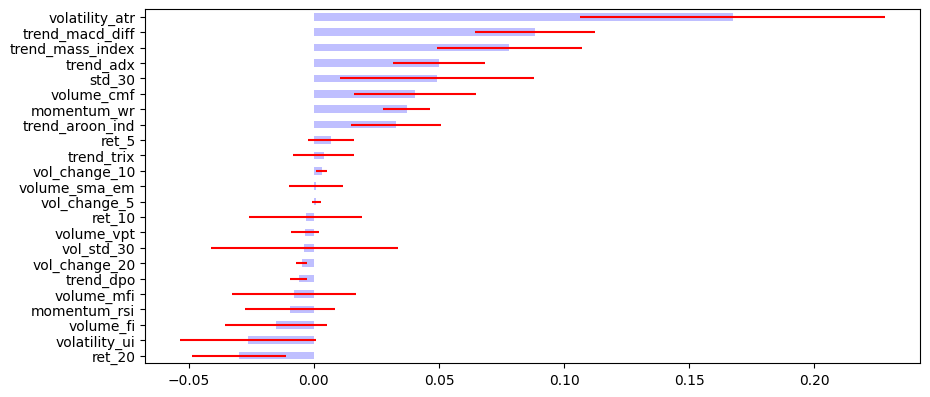

In [43]:
# feat_imp 확인
plot_feature_importance(feat_imp)

# feat_imp_mda 확인
plot_feature_importance(feat_imp_mda)

<br>

#### **RFE CV, Recursive Feature Elimination**

In [44]:
# Q. 코드를 작성해주세요

In [45]:
# RFE CV, Recursive Feature Elimination
svc_rbf = SVC(kernel='linear', probability=True)
rfe_cv = RFECV(svc_rbf, cv=cv) # RFECV
rfe_fitted = rfe_cv.fit(X_sc, y) # fit

In [46]:
# 선택된 피쳐 확인하기

In [47]:
rfe_df = pd.DataFrame([rfe_fitted.support_, rfe_fitted.ranking_], columns=X_sc.columns).T.rename(columns={0:"Optimal_Features", 1:"Ranking"})
rfe_df

,Optimal_Features,Ranking
volume_cmf,False,12
volume_fi,False,4
volume_mfi,False,14
volume_sma_em,False,7
volume_vpt,False,8
volatility_atr,True,1
volatility_ui,False,11
trend_macd_diff,True,1
trend_adx,False,19
trend_trix,False,10


In [48]:
rfe_df[rfe_df["Optimal_Features"]==True]

,Optimal_Features,Ranking
volatility_atr,True,1
trend_macd_diff,True,1
std_30,True,1


<br>

#### **SFS, Sequential Feature Selection**

In [49]:
# SFS, Sequential Feature Selection

In [50]:
n = 2

sfs_forward = SequentialFeatureSelector(svc_rbf, n_features_to_select=n, direction='forward')
sfs_fitted = sfs_forward.fit(X_sc, y)

In [52]:
# 선택된 피쳐 확인하기
sfs_rank = sfs_fitted.get_support()
sfs_df = pd.DataFrame(sfs_rank, index=X_sc.columns, columns=["Optimal_Features"])

sfs_df [sfs_df ["Optimal_Features"]==True].index

Index(['volume_mfi', 'trend_macd_diff'], dtype='object')

<br>

#### **SHAP, Shapley Additive explanations**

In [ ]:
# Q. 코드를 작성해주세요

In [53]:
import shap
explainer = shap.TreeExplainer(rfc)
shap_value = explainer.shap_values(X_sc)

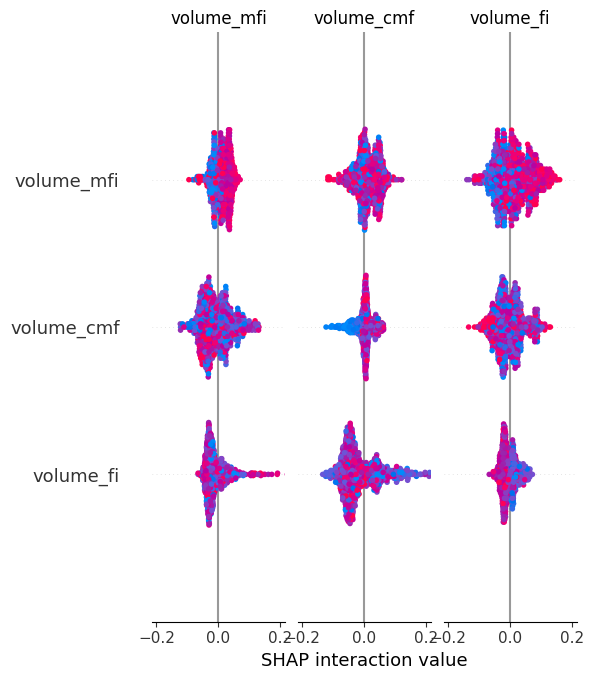

In [54]:
# shap_value, X_sc 사용 shap.summary_plot 그리기
shap.summary_plot(shap_value, X_sc)

In [55]:
output_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_feature_labels.pkl')
df_tmp_data.to_pickle(output_file_name)

<br><br>

## **프로젝트 3: Model Traning**

---

① 환경구성 및 데이터 불러오기

② Purged K-fold for Cross-Validation적용하기

③ Model 적용하기

<br>

#### **환경구성 및 데이터 불러오기**

In [58]:
# 필요 라이브러리

In [57]:
import datetime
import sys
import os
import re
import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ta

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score, roc_curve

sys.path.append('/content/drive/MyDrive/DS_8th/06_금융 시계열 분석하기/45일차_2 24(화)_시계열분석 기초_09(프로젝트)/fnguide/data/')
from libs.mlutil.pkfold import PKFold

In [59]:
# 데이터 경로 설정 및 pickle 파일 불러오기

In [60]:
DATA_PATH = '/content/drive/MyDrive/DS_8th/06_금융 시계열 분석하기/45일차_2 24(화)_시계열분석 기초_09(프로젝트)/fnguide/data/'
data_file_name = os.path.join(DATA_PATH, 'sub_upbit_eth_min_feature_labels.pkl')

In [61]:
# 여기서부터 모델에 적용하기 위한 데이터 정제화를 시작합니다.

In [63]:
df_data = pd.read_pickle(data_file_name)
df_data['t_value'] = df_data['t_value'].apply(lambda x: x if x == 1 else 0)

df_data['t_value'].value_counts()

,count
t_value,
1.0,481
0.0,476


In [64]:
# 데이터셋 비율 나누기
train_ratio, test_ratio = 0.7, 0.2
n_train = int(np.round(len(df_data) * train_ratio))
n_test = int(np.round(len(df_data) * test_ratio))

X, y = df_data.iloc[:, 5:-1], df_data.iloc[:, -1]

In [65]:
# standardzation
sc = StandardScaler()
X_sc = sc.fit_transform(X)

In [66]:
# 데이터셋 분리
train_x, test_x, train_y, test_y = X_sc[:n_train, :], X_sc[-n_test:, :], y.iloc[:n_train], y.iloc[-n_test:]

train_x = pd.DataFrame(train_x, index=train_y.index, columns=X.columns)
train_y = pd.Series(train_y, index=train_y.index)
test_x = pd.DataFrame(test_x, index=test_y.index, columns=X.columns)
test_y = pd.Series(test_y, index=test_y.index)

In [67]:
# 학습 시간 단축을 위해 여기선 편의상 1000개의 데이터만 가져옵니다.
train_x = train_x[:1000] # 데이터셋을 증가 혹은 감소시켜 결과를 비교해봅시다.
train_y = train_y[:1000]

<br>

### **① Purged K-fold for Cross-Validation적용하기**

In [68]:
# Q. 코드를 작성해주세요

In [69]:
n_cv = 4 # 앞에서 지정한 값은 4입니다. 얼마를 넣을지 생각해보고 왜 이 값을 넣었는지에 대해서 설명해봅시다.
t1 = pd.Series(train_y.index.values, index=train_y.index)

# purged K-Fold
cv = PKFold(n_cv, t1, 0)

<br>

### **② Model 적용하기**

In [78]:
# GridsearchCV에서 사용할 파라미터 설정합니다. 파라미터값을 바꿔보세요
bc_params = {
    'n_estimators': [5, 10, 20],
    'max_features': [0.5, 0.7],
    'estimator__max_depth': [3, 5, 10, 20],
    'estimator__max_features': [None, 'auto'],   # 아래 참고
    'estimator__min_samples_leaf': [3, 5, 10],
    'bootstrap_features': [False, True]
}

In [79]:
# RandomForest 사용
rfc = RandomForestClassifier(class_weight='balanced')

In [80]:
# Q. 코드를 작성해주세요

In [81]:
# Bagging 적용
bag_rfc = BaggingClassifier(rfc)

In [82]:
# Q. 코드를 작성해주세요

In [83]:
# GridSearchCV 적용
gs_rfc = GridSearchCV(bag_rfc, bc_params, cv=cv, n_jobs=-1, verbose=1)

In [84]:
# fit
gs_rfc.fit(train_x, train_y)

# best estimator
gs_rfc_best = gs_rfc.best_estimator_

Fitting 4 folds for each of 288 candidates, totalling 1152 fits


In [85]:
gs_rfc_best.fit(train_x, train_y)

BaggingClassifier(estimator=RandomForestClassifier(class_weight='balanced',
                                                   max_depth=10,
                                                   max_features=None,
                                                   min_samples_leaf=10),
                  max_features=0.7, n_estimators=5)

In [86]:
# 예측값 확인
pred_y = gs_rfc_best.predict(test_x)
prob_y = gs_rfc_best.predict_proba(test_x)

In [87]:
# Q. 코드를 작성해주세요

In [88]:
# test_y, pred_y를 활용한 지표 적용
confusion = confusion_matrix(test_y, pred_y)
accuracy  = accuracy_score(test_y, pred_y)
precision = precision_score(test_y, pred_y)
recall    = recall_score(test_y, pred_y)

# 지표를 통한 결과 확인
print('================= confusion matrix ====================')
print(confusion)
print('=======================================================')
print(f'정확도:{accuracy}, 정밀도:{precision}, 재현율:{recall}')

================= confusion matrix ====================
[[79 57]
 [13 42]]
정확도:0.6335078534031413, 정밀도:0.42424242424242425, 재현율:0.7636363636363637


In [90]:
# Q. 코드를 작성해주세요

auc:0.67225935828877


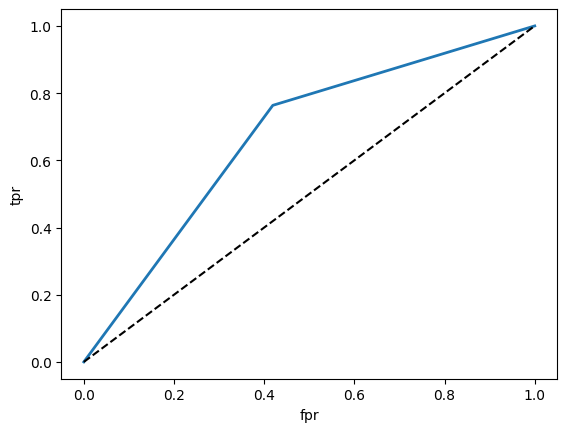

In [91]:
# ROC curve 만들기
fpr, tpr, thresholds = roc_curve(test_y, pred_y)
auc = roc_auc_score(test_y, pred_y)

# ROC curve 시각화
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
plt.xlabel('fpr')
plt.ylabel('tpr')
print(f'auc:{auc}')

<br>

## **모델 성능 개선 맻 비교 분석**

---

### **전략 1: Bagging 제거 및 RandomForest 단독 튜닝**

#### **목적**

- 중복된 Bagging 구조 제거
- 학습 시간 단축 기대
- RandomForest 자체 성능 극대화

#### **개선 포인트**

- n_estimators 증가
- max_depth, min_samples_leaf 조정
- max_features 최적화
- PKFold 기반 교차검증 유지

In [92]:
# 필요 라이브러리 import
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [93]:
# 공통: 결과 출력 함수
def print_metrics(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    print(f"\n================= {name} ====================")
    print("confusion matrix")
    print(cm)
    print("------------------------------------------------")
    print(f"정확도(accuracy): {acc:.4f}")
    print(f"정밀도(precision): {pre:.4f}")
    print(f"재현율(recall): {rec:.4f}")
    return {"name": name, "accuracy": acc, "precision": pre, "recall": rec, "cm": cm}

In [94]:
# (1) 모델 정의
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [97]:
# (2) 파라미터 그리드 (너무 크지 않게: 가성비 위주)
rf_param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [None, 5, 10, 20],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"]
}

In [98]:
# (3) 탐색기: RandomizedSearchCV
gs_rf = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [99]:
# 학습
gs_rf.fit(train_x, train_y)
best_rf = gs_rf.best_estimator_

Fitting 4 folds for each of 48 candidates, totalling 192 fits


In [100]:
# 기본 예측(Threshold=0.5)
pred_rf = best_rf.predict(test_x)
res1 = print_metrics("전략1-RF(기본 threshold=0.5)", test_y, pred_rf)


================= 전략1-RF(기본 threshold=0.5) ====================
confusion matrix
[[77 59]
 [11 44]]
------------------------------------------------
정확도(accuracy): 0.6335
정밀도(precision): 0.4272
재현율(recall): 0.8000


<br>

### **전략 2: 예측 확률 기반 Threshold 최적화**

- 목적: False Positive 감소 → Precision 및 Accuracy 개선

- 방법: predict_proba 확률값을 기반으로 다양한 threshold 실험

In [103]:
# 1) 확률값 추출

In [104]:
prob_rf = best_rf.predict_proba(test_x)[:, 1]
prob_rf

array([0.66820437, 0.67933962, 0.55614378, 0.34540797, 0.15947217,
       0.12540519, 0.11895911, 0.10498986, 0.10926995, 0.14794744,
       0.44571685, 0.42442813, 0.53364369, 0.58295905, 0.80544545,
       0.78614948, 0.71982048, 0.70871949, 0.70653993, 0.41957937,
       0.69899249, 0.26885067, 0.18159772, 0.15543702, 0.11605853,
       0.13864639, 0.13246622, 0.11674615, 0.06475633, 0.05336439,
       0.14728337, 0.32063398, 0.40291143, 0.39195406, 0.31057536,
       0.27836114, 0.21926064, 0.2500135 , 0.32886634, 0.60670384,
       0.42025257, 0.16272415, 0.14092612, 0.13404441, 0.13499076,
       0.20017078, 0.22621866, 0.27936134, 0.62253649, 0.69243238,
       0.70973237, 0.76606137, 0.80892505, 0.78143399, 0.76027593,
       0.81198542, 0.75192355, 0.78852966, 0.79544044, 0.74209478,
       0.73109942, 0.78106523, 0.76316025, 0.80042494, 0.85080953,
       0.85281265, 0.85129123, 0.84131019, 0.82425321, 0.78725232,
       0.77427889, 0.87044167, 0.84499429, 0.87611154, 0.79931

In [105]:
# 2) 다양한 threshold 탐색

In [106]:
thresholds = np.arange(0.40, 0.81, 0.02)

results = []

for th in thresholds:
    pred_th = (prob_rf >= th).astype(int)

    acc = accuracy_score(test_y, pred_th)
    pre = precision_score(test_y, pred_th, zero_division=0)
    rec = recall_score(test_y, pred_th, zero_division=0)

    results.append([th, acc, pre, rec])

In [107]:
threshold_df = pd.DataFrame(results, columns=["threshold", "accuracy", "precision", "recall"])

In [108]:
# 3) Accuracy 기준 상위 결과 확인

In [109]:
print("\n================= Threshold 탐색 결과 (Accuracy 기준 상위 10개) =================")
display(threshold_df.sort_values("accuracy", ascending=False).head(10))


================= Threshold 탐색 결과 (Accuracy 기준 상위 10개) =================


,threshold,accuracy,precision,recall
17,0.74,0.811518,0.711111,0.581818
16,0.72,0.806283,0.680000,0.618182
15,0.70,0.795812,0.642857,0.654545
18,0.76,0.795812,0.690476,0.527273
14,0.68,0.785340,0.612903,0.690909
19,0.78,0.785340,0.694444,0.454545
20,0.80,0.764398,0.692308,0.327273
12,0.64,0.764398,0.571429,0.727273
13,0.66,0.764398,0.573529,0.709091
11,0.62,0.759162,0.561644,0.745455


In [110]:
# 4) Precision 기준 상위 결과 확인

In [111]:
print("\n================= Threshold 탐색 결과 (Precision 기준 상위 10개) =================")
display(threshold_df.sort_values("precision", ascending=False).head(10))


================= Threshold 탐색 결과 (Precision 기준 상위 10개) =================


,threshold,accuracy,precision,recall
17,0.74,0.811518,0.711111,0.581818
19,0.78,0.785340,0.694444,0.454545
20,0.80,0.764398,0.692308,0.327273
18,0.76,0.795812,0.690476,0.527273
16,0.72,0.806283,0.680000,0.618182
15,0.70,0.795812,0.642857,0.654545
14,0.68,0.785340,0.612903,0.690909
13,0.66,0.764398,0.573529,0.709091
12,0.64,0.764398,0.571429,0.727273
11,0.62,0.759162,0.561644,0.745455


In [112]:
# 5) Accuracy 기준 최적 threshold 선택

In [114]:
best_th = threshold_df.sort_values("accuracy", ascending=False).iloc[0]["threshold"]
print(f"\n선택된 최적 Threshold (Accuracy 기준): {best_th:.2f}")


선택된 최적 Threshold (Accuracy 기준): 0.74


In [115]:
# 6) 최적 threshold로 최종 예측

In [116]:
final_pred = (prob_rf >= best_th).astype(int)
final_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [117]:
# 7) 최종 성능 출력

In [118]:
cm = confusion_matrix(test_y, final_pred)
acc = accuracy_score(test_y, final_pred)
pre = precision_score(test_y, final_pred, zero_division=0)
rec = recall_score(test_y, final_pred, zero_division=0)

In [119]:
print("\n================= 전략2-RF(Threshold 최적화 적용) ====================")
print("confusion matrix")
print(cm)
print("------------------------------------------------")
print(f"정확도(accuracy): {acc:.4f}")
print(f"정밀도(precision): {pre:.4f}")
print(f"재현율(recall): {rec:.4f}")


================= 전략2-RF(Threshold 최적화 적용) ====================
confusion matrix
[[123  13]
 [ 23  32]]
------------------------------------------------
정확도(accuracy): 0.8115
정밀도(precision): 0.7111
재현율(recall): 0.5818


In [137]:
# classification_report 출력

In [136]:
from sklearn.metrics import classification_report

print("\n================= classification_report (전략2 최종) =================")
print(classification_report(test_y, final_pred, digits=4, zero_division=0))


================= classification_report (전략2 최종) =================
              precision    recall  f1-score   support

         0.0     0.8425    0.9044    0.8723       136
         1.0     0.7111    0.5818    0.6400        55

    accuracy                         0.8115       191
   macro avg     0.7768    0.7431    0.7562       191
weighted avg     0.8046    0.8115    0.8054       191



In [138]:
# ROC-AUC + ROC Curve

In [139]:
roc_auc = roc_auc_score(test_y, prob_rf)
fpr, tpr, roc_th = roc_curve(test_y, prob_rf)

print("\n================= ROC-AUC =================")
print(f"ROC-AUC: {roc_auc:.4f}")


================= ROC-AUC =================
ROC-AUC: 0.8130


In [143]:
# threshold(best_th) 지점(운영점) 표시
op_idx = np.argmin(np.abs(roc_th - best_th))
op_fpr, op_tpr = fpr[op_idx], tpr[op_idx]

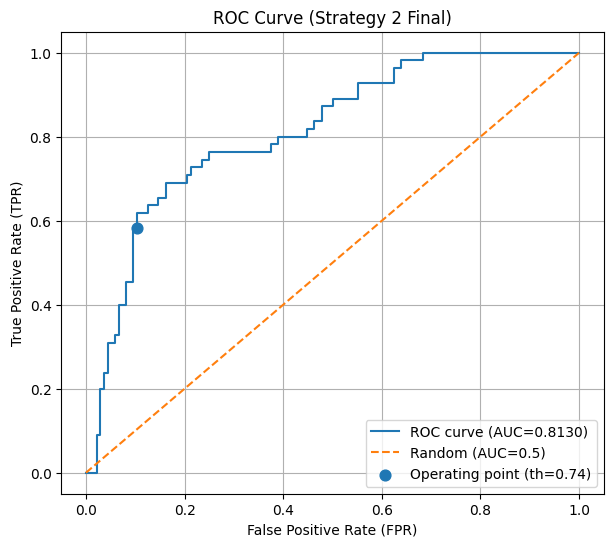

In [144]:
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC=0.5)")
plt.scatter(op_fpr, op_tpr, s=60, label=f"Operating point (th={best_th:.2f})")
plt.title("ROC Curve (Strategy 2 Final)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.grid(True)
plt.legend(loc="lower right")
plt.show()

In [146]:
# Threshold-지표 곡선 (Precision/Recall/F1)

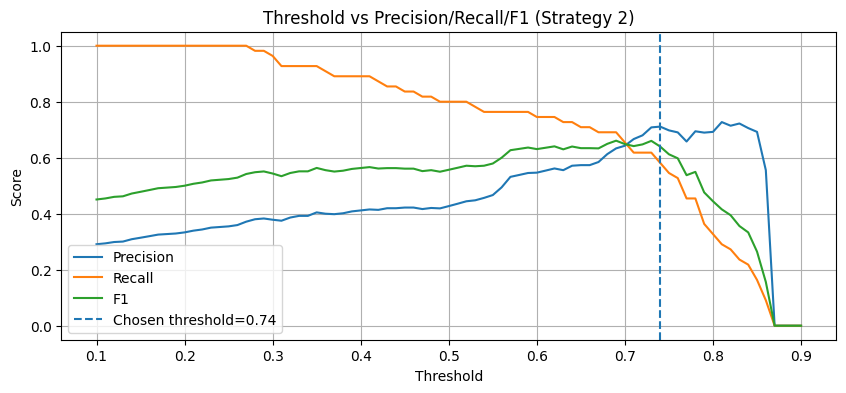

In [145]:
ths = np.arange(0.10, 0.91, 0.01)
prec_list, rec_list, f1_list = [], [], []

for th in ths:
    pred_t = (prob_rf >= th).astype(int)
    p = ( (pred_t == 1) & (test_y == 1) ).sum() / max((pred_t == 1).sum(), 1)  # precision 안전 계산
    r = ( (pred_t == 1) & (test_y == 1) ).sum() / max((test_y == 1).sum(), 1)  # recall
    f = f1_score(test_y, pred_t, zero_division=0)
    prec_list.append(p)
    rec_list.append(r)
    f1_list.append(f)

plt.figure(figsize=(10, 4))
plt.plot(ths, prec_list, label="Precision")
plt.plot(ths, rec_list, label="Recall")
plt.plot(ths, f1_list, label="F1")
plt.axvline(best_th, linestyle="--", label=f"Chosen threshold={best_th:.2f}")
plt.title("Threshold vs Precision/Recall/F1 (Strategy 2)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.show()

In [148]:
# F1 기준 test에서 가장 높은 threshold 확인

In [149]:
best_th_f1_test = ths[int(np.argmax(f1_list))]
print("\n[참고] test 기준 F1 최대 threshold:", f"{best_th_f1_test:.2f}",
      "| F1:", f"{max(f1_list):.4f}")


[참고] test 기준 F1 최대 threshold: 0.69 | F1: 0.6609


<br><br>

## **9-7. 프로젝트 제출**

---

### **루브릭**

| 평가문항 | 상세기준 | 수행여부 |
|----------|----------|----------|
| 1. 프로젝트 1, 2를 정상적인 흐름대로 진행하였는가? | 데이터 라벨링 방법 4가지 및 각종 지표를 적용한 데이터셋을 활용하여 특성선택을 시도하였다. | O |
| 2. 프로젝트 3에서 다양한 방법을 사용하여 기존의 결과와 비교 분석 시도하였는가? | PKFold의 split 개수, 데이터 비율, 데이터 개수 등의 파라미터 변경 및 모델 변경을 시도하고 기존의 결과와 비교하였다. | O |
| 3. 다양한 방법을 사용하여 성능향상을 시도하였는가? | classification report에서 accuracy, precision, recall의 성능을 5% 이상 향상 시켰다. | O |